# Exploratory Data Analysis
## Respiratory Disease Prediction from Environmental Factors


---

## Input

`data/processed/master_daily.csv` - 1,133 rows, 7 columns, Sep 2022 to Oct 2025

## Output

```
outputs/figures/
    eda_01_correlation_heatmap.png
    eda_02_correlation_barplot.png
    eda_03_scatter_features_vs_target.png
    eda_04_seasonal_decomposition.png
    eda_05_monthly_boxplots.png
    eda_06_lag_correlations.png
    eda_07_overlay_respiratory_vs_features.png
    eda_08_rolling_correlation.png
```

## Setup

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings('ignore')
os.makedirs('outputs/figures', exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 9

FEATURES = ['pm25', 'no2', 'ozone', 'temperature', 'humidity']
TARGET   = 'pct_respiratory'
LABELS   = {
    'pct_respiratory': 'Respiratory % ED Visits',
    'pm25':            'PM2.5 (ug/m3)',
    'no2':             'NO2 (ppb)',
    'ozone':           'Ozone (ppm)',
    'temperature':     'Temperature (F)',
    'humidity':        'Relative Humidity (%)',
}
COLORS = {
    'pct_respiratory': '#d62728',
    'pm25':            '#1f77b4',
    'no2':             '#2ca02c',
    'ozone':           '#ff7f0e',
    'temperature':     '#e377c2',
    'humidity':        '#17becf',
}

# Load master dataset
master = pd.read_csv('data/processed/master_daily.csv', parse_dates=['date'])
master = master.sort_values('date').reset_index(drop=True)

# Add time features - used throughout EDA
master['month']      = master['date'].dt.month
master['month_name'] = master['date'].dt.strftime('%b')
master['year']       = master['date'].dt.year
master['dayofweek']  = master['date'].dt.dayofweek  # 0=Mon, 6=Sun
master['season']     = master['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring',  4: 'Spring', 5: 'Spring',
    6: 'Summer',  7: 'Summer', 8: 'Summer',
    9: 'Fall',   10: 'Fall',  11: 'Fall',
})

print(f'Master dataset loaded: {master.shape}')
print(f'Date range: {master["date"].min().date()} to {master["date"].max().date()}')
display(master[FEATURES + [TARGET]].describe().T)

Master dataset loaded: (1133, 12)
Date range: 2022-09-25 to 2025-10-31


,count,mean,std,min,25%,50%,75%,max
pm25,1133.0,7.595527,2.028565,3.582884,6.214627,7.267829,8.608193,20.404264
no2,1133.0,7.591773,2.225989,3.029693,5.958280,7.157784,9.098816,16.773389
ozone,1133.0,0.032298,0.005523,0.018465,0.027976,0.032844,0.036736,0.045308
temperature,1133.0,57.721445,14.580413,21.809399,45.060003,58.108956,70.833313,80.899611
humidity,1133.0,60.182063,7.207458,43.718824,54.917564,59.118099,64.553997,85.913518
pct_respiratory,1133.0,13.242242,4.078128,7.090000,10.350000,12.160000,15.510000,26.580000


---
## EDA 1 - Correlation Matrix

Pearson correlation between all variables.
This gives the first quantitative answer to which features relate to the target.

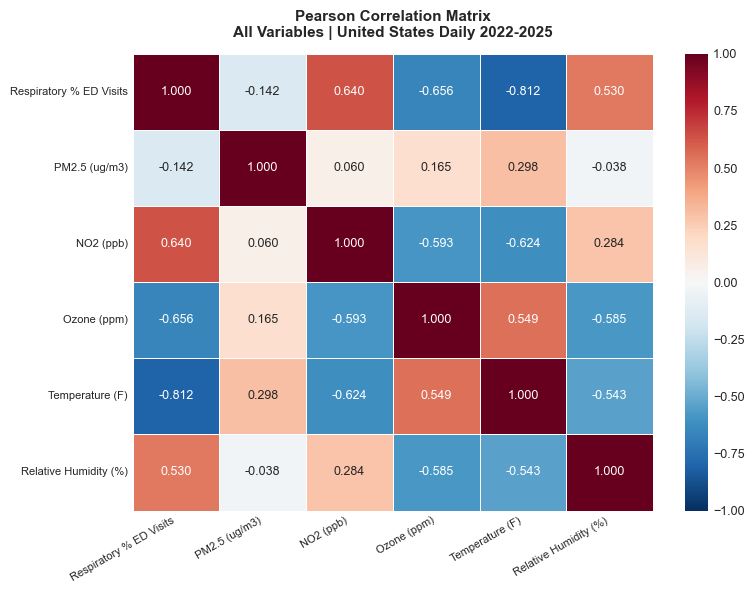

Correlation with target (sorted by absolute value):
  Temperature (F)                 r = -0.812  (negative)
  Ozone (ppm)                     r = -0.656  (negative)
  NO2 (ppb)                       r = +0.640  (positive)
  Relative Humidity (%)           r = +0.530  (positive)
  PM2.5 (ug/m3)                   r = -0.142  (negative)


In [2]:
corr_cols = [TARGET] + FEATURES
corr = master[corr_cols].corr()

tick_labels = [LABELS[c] for c in corr_cols]

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, annot=True, fmt='.3f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    xticklabels=tick_labels, yticklabels=tick_labels,
    linewidths=0.5, ax=ax
)
ax.set_title('Pearson Correlation Matrix\nAll Variables | United States Daily 2022-2025',
             fontsize=11, fontweight='bold', pad=12)
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('outputs/figures/eda_01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation with target (sorted by absolute value):')
target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
for feat, val in target_corr.items():
    direction = 'positive' if val > 0 else 'negative'
    print(f'  {LABELS[feat]:<30}  r = {val:+.3f}  ({direction})')

## EDA 2 - Correlation Bar Plot

Visual ranking of each feature's correlation with the target.

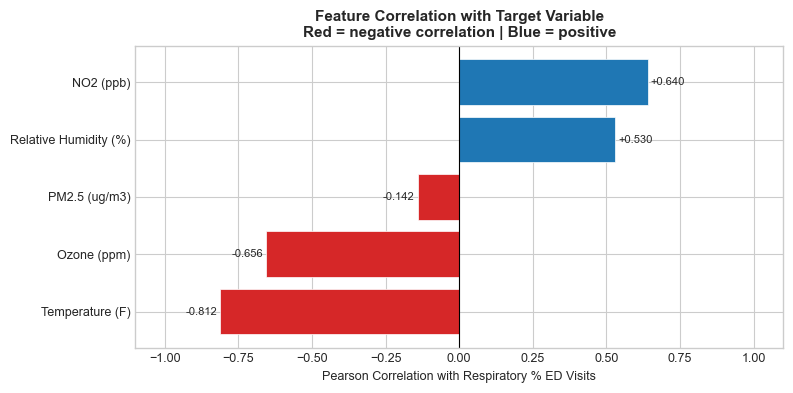

In [3]:
target_corr_sorted = corr[TARGET].drop(TARGET).sort_values()
bar_colors = ['#d62728' if v < 0 else '#1f77b4' for v in target_corr_sorted]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    [LABELS[f] for f in target_corr_sorted.index],
    target_corr_sorted.values,
    color=bar_colors, edgecolor='white', linewidth=0.5
)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, target_corr_sorted.values):
    x = val + 0.01 if val >= 0 else val - 0.01
    ha = 'left' if val >= 0 else 'right'
    ax.text(x, bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=8)

ax.set_xlabel('Pearson Correlation with Respiratory % ED Visits', fontsize=9)
ax.set_title('Feature Correlation with Target Variable\nRed = negative correlation | Blue = positive',
             fontsize=11, fontweight='bold')
ax.set_xlim(-1.1, 1.1)
plt.tight_layout()
plt.savefig('outputs/figures/eda_02_correlation_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## EDA 3 - Scatter Plots with Regression Lines

One scatter per feature vs target with Pearson r and p-value.
Color-coded by season to reveal whether relationships are seasonally driven.

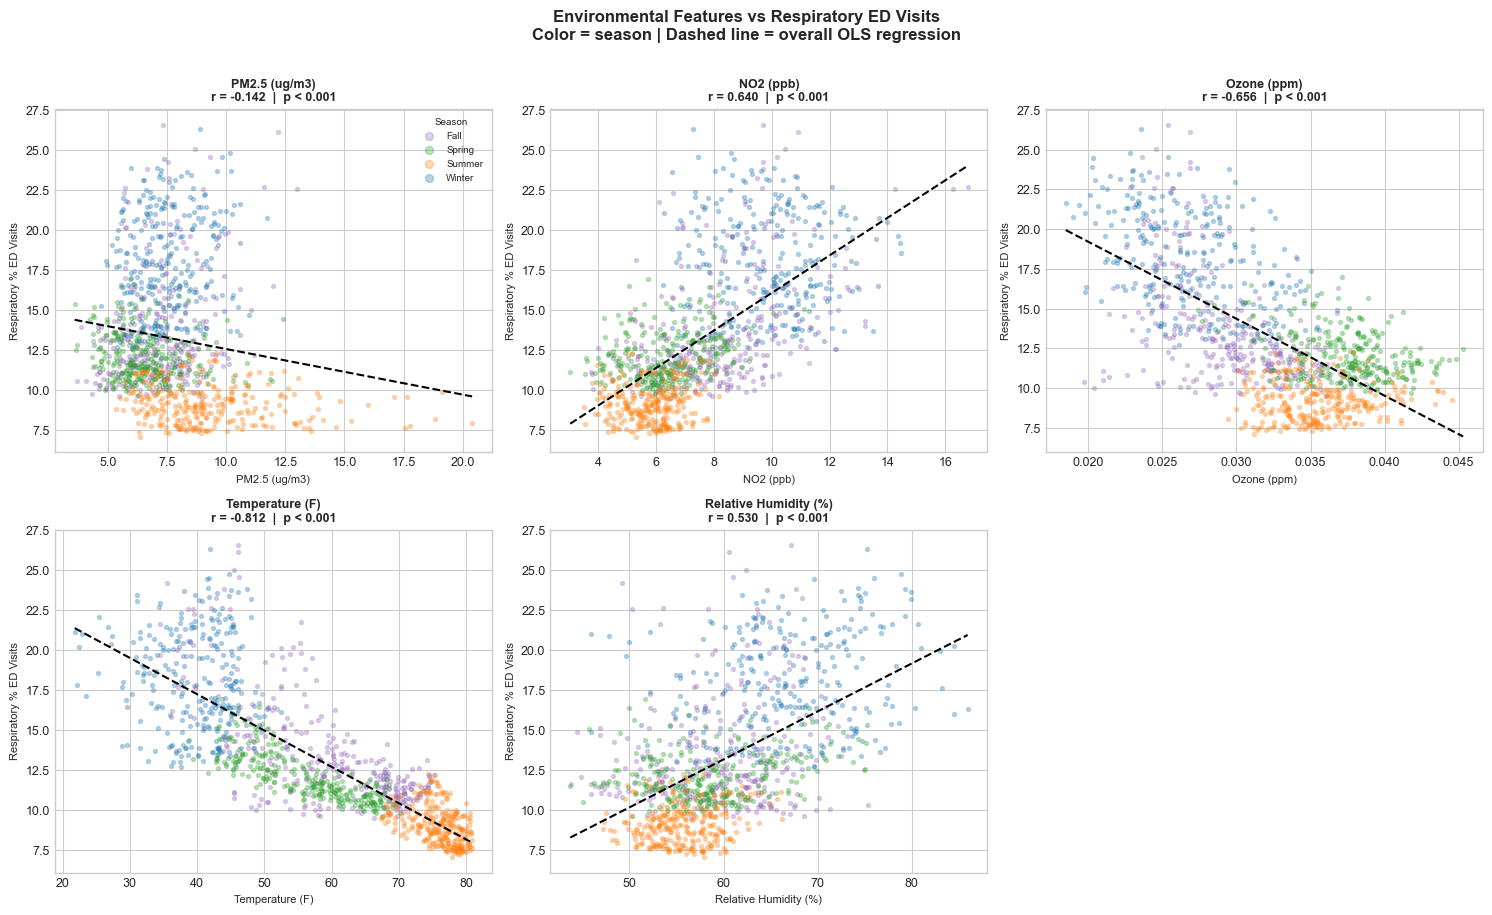

In [4]:
SEASON_COLORS = {'Winter': '#1f77b4', 'Spring': '#2ca02c',
                 'Summer': '#ff7f0e', 'Fall':   '#9467bd'}

n = len(FEATURES)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    for season, grp in master.groupby('season'):
        ax.scatter(
            grp[feat], grp[TARGET],
            alpha=0.3, s=8,
            color=SEASON_COLORS[season],
            label=season
        )
    # Overall regression line
    clean = master[[feat, TARGET]].dropna()
    slope, intercept, r, p, _ = stats.linregress(clean[feat], clean[TARGET])
    xs = np.linspace(clean[feat].min(), clean[feat].max(), 100)
    ax.plot(xs, slope * xs + intercept, color='black', linewidth=1.5, linestyle='--')
    p_str = f'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
    ax.set_title(f'{LABELS[feat]}\nr = {r:.3f}  |  {p_str}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel(LABELS[feat], fontsize=8)
    ax.set_ylabel(LABELS[TARGET], fontsize=8)
    if i == 0:
        ax.legend(title='Season', fontsize=7, title_fontsize=7,
                  loc='upper right', markerscale=2)

# Hide the unused 6th subplot
axes[-1].set_visible(False)

fig.suptitle('Environmental Features vs Respiratory ED Visits\n'
             'Color = season | Dashed line = overall OLS regression',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/figures/eda_03_scatter_features_vs_target.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## EDA 4 - Seasonal Decomposition

Decompose the respiratory illness time series into trend, seasonality, and residual.
This reveals whether the correlations we see are driven by shared seasonality
or by independent variation within seasons.

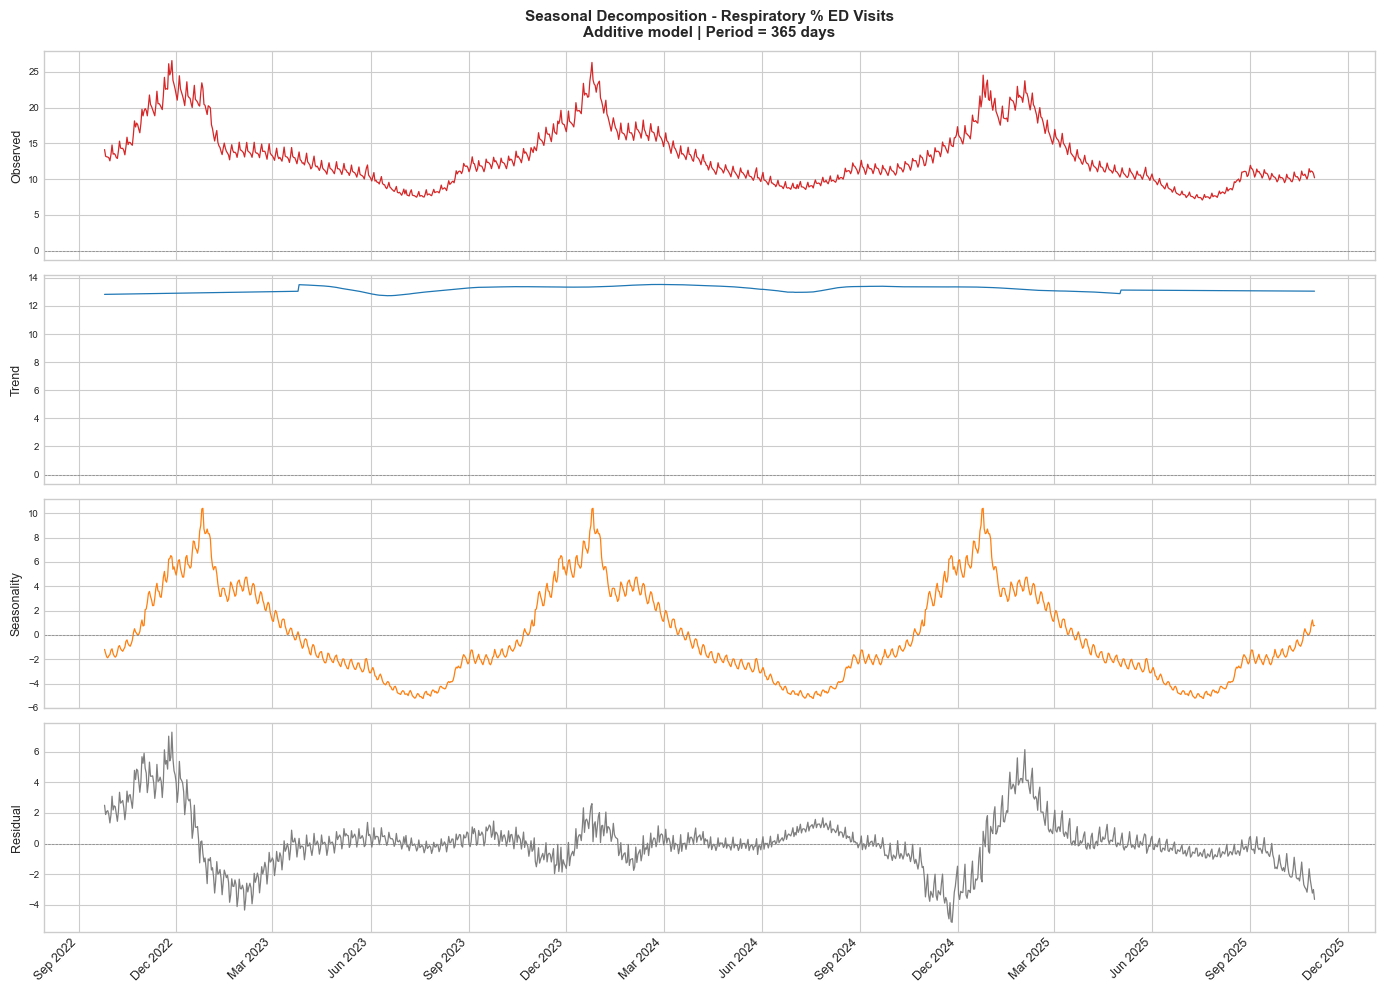

Variance explained by each component:
  Seasonal:  81.4%
  Trend:     0.2%
  Residual:  17.5%


In [5]:
# Use 365-day period for annual seasonality
# Requires a continuous series - use the cleaned respiratory column
resp_series = master.set_index('date')[TARGET]

decomp = seasonal_decompose(resp_series, model='additive', period=365, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

components = [
    (resp_series,      'Observed',    '#d62728'),
    (decomp.trend,     'Trend',       '#1f77b4'),
    (decomp.seasonal,  'Seasonality', '#ff7f0e'),
    (decomp.resid,     'Residual',    '#7f7f7f'),
]

for ax, (series, label, color) in zip(axes, components):
    ax.plot(series.index, series.values, color=color, linewidth=0.9)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis='y', labelsize=7)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

axes[0].set_title(
    'Seasonal Decomposition - Respiratory % ED Visits\n'
    'Additive model | Period = 365 days',
    fontsize=11, fontweight='bold', pad=10
)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/figures/eda_04_seasonal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Report variance explained by each component
total_var = resp_series.var()
print('Variance explained by each component:')
print(f'  Seasonal:  {decomp.seasonal.var() / total_var * 100:.1f}%')
print(f'  Trend:     {decomp.trend.var() / total_var * 100:.1f}%')
print(f'  Residual:  {decomp.resid.var() / total_var * 100:.1f}%')

---
## EDA 5 - Monthly Box Plots

Distribution of each variable by calendar month.
Shows within-month variability and confirms seasonal patterns.

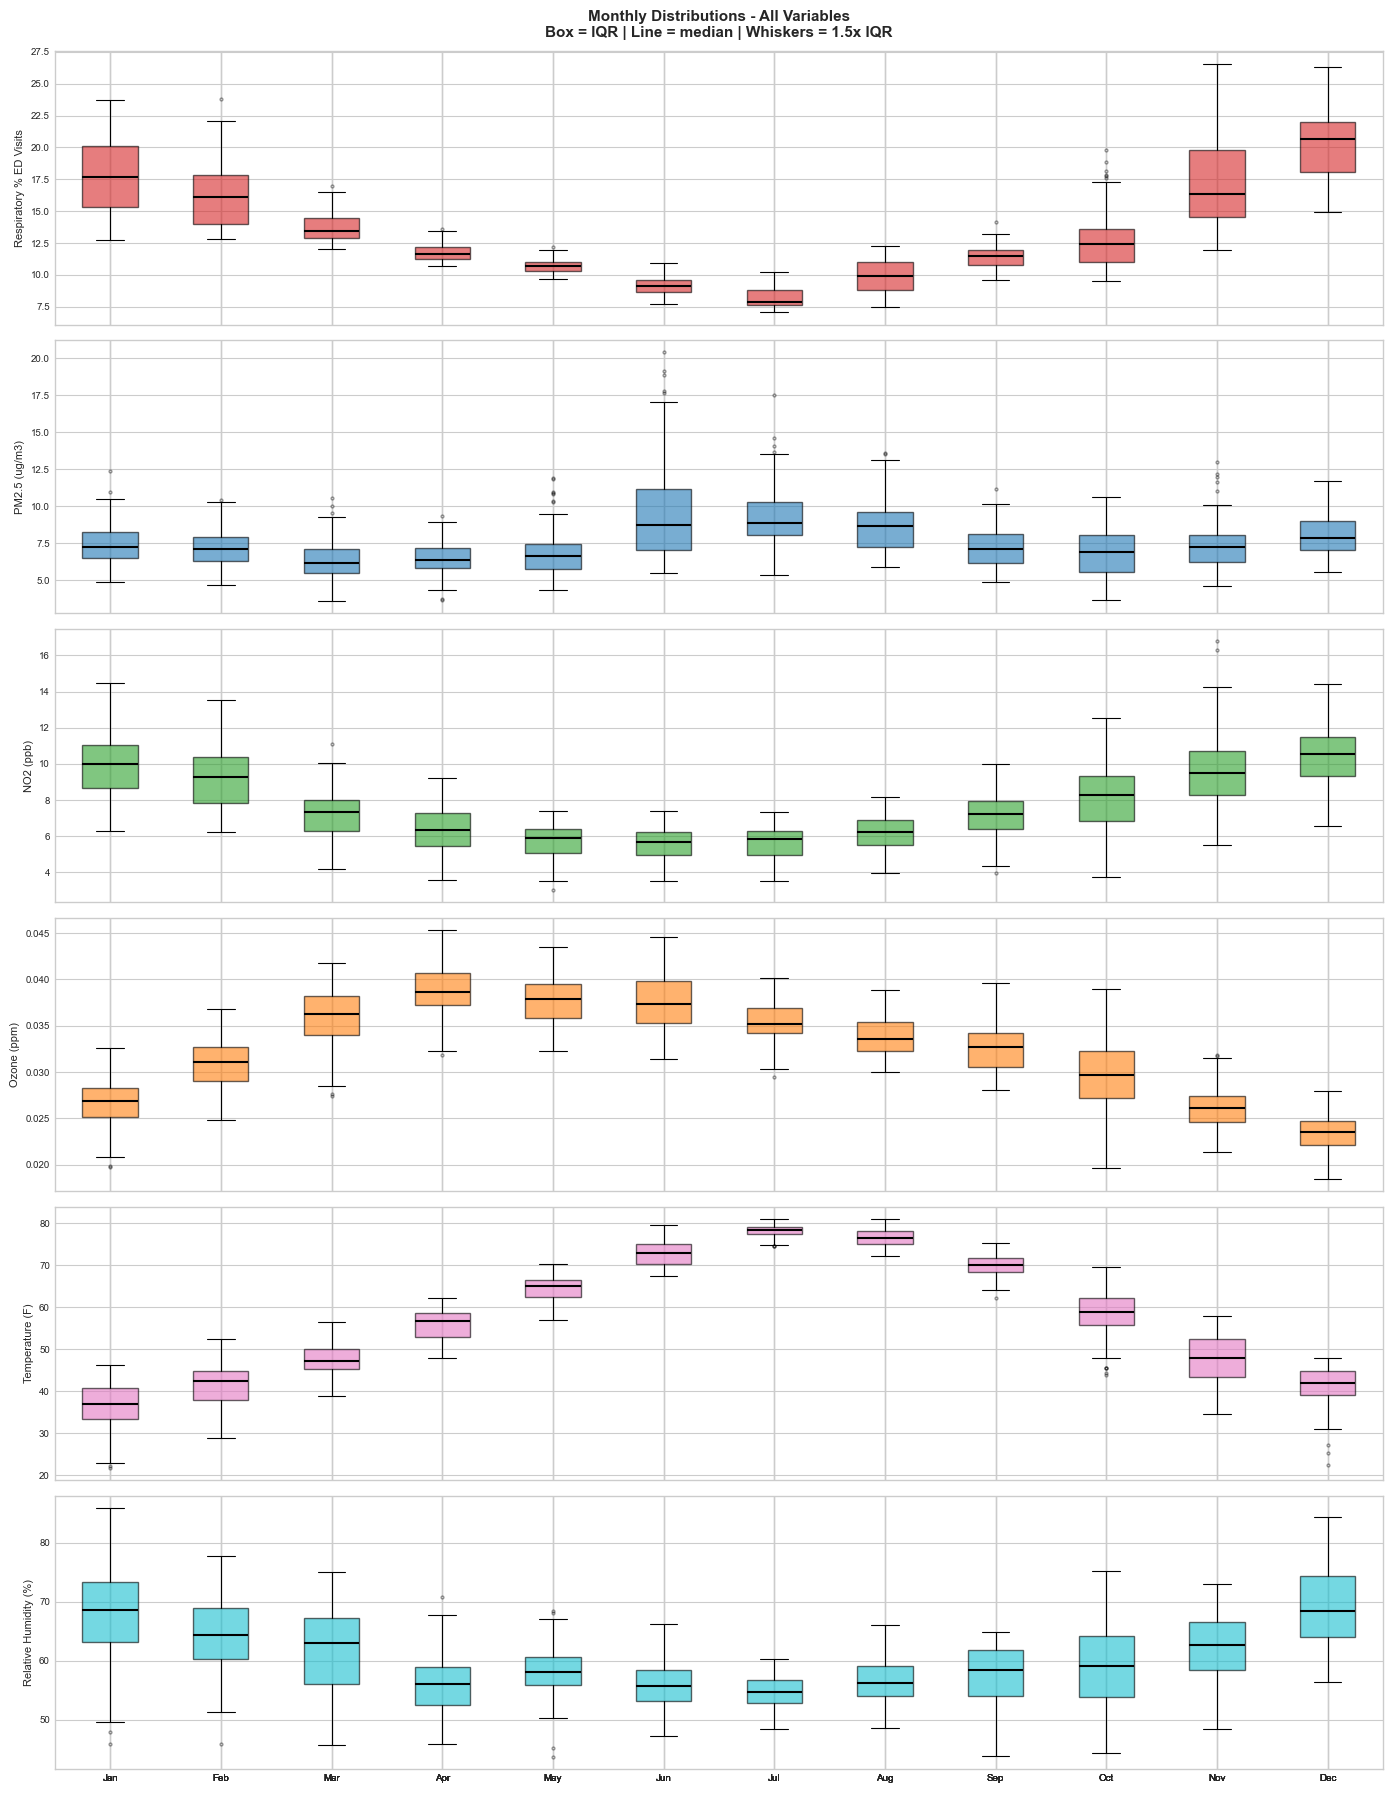

In [6]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plot_cols = [TARGET] + FEATURES
n = len(plot_cols)
fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=True)

for ax, col in zip(axes, plot_cols):
    monthly = [
        master[master['month_name'] == m][col].dropna().values
        for m in month_order
    ]
    bp = ax.boxplot(
        monthly, labels=month_order,
        patch_artist=True, notch=False,
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        flierprops=dict(marker='o', markersize=2, alpha=0.4),
    )
    for patch in bp['boxes']:
        patch.set_facecolor(COLORS[col])
        patch.set_alpha(0.6)
    ax.set_ylabel(LABELS[col], fontsize=8)
    ax.tick_params(axis='both', labelsize=7)

axes[0].set_title(
    'Monthly Distributions - All Variables\n'
    'Box = IQR | Line = median | Whiskers = 1.5x IQR',
    fontsize=11, fontweight='bold', pad=10
)
plt.tight_layout()
plt.savefig('outputs/figures/eda_05_monthly_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## EDA 6 - Lag Correlation Analysis

Environmental exposure doesn’t cause illness immediately - a person exposed to high PM2.5 on Monday might only show symptoms and visit the ED on Wednesday or Thursday. To account for this, we check correlations at lags from 0 up to 14 days to see which lag best relates each feature to the target.

The lag that shows the strongest correlation is then used as a feature in the model. For example, pm25_lag3 would represent the PM2.5 value from 3 days earlier.

In [7]:
MAX_LAG = 14
lag_results = {}

for feat in FEATURES:
    correlations = []
    p_values     = []
    for lag in range(0, MAX_LAG + 1):
        # Lag the feature: compare feature from 'lag' days ago with today's target
        lagged  = master[feat].shift(lag)
        target  = master[TARGET]
        valid   = ~(lagged.isna() | target.isna())
        r, p    = stats.pearsonr(lagged[valid], target[valid])
        correlations.append(r)
        p_values.append(p)
    lag_results[feat] = {'correlations': correlations, 'p_values': p_values}

# Find optimal lag for each feature
print('Optimal lag for each feature (strongest absolute correlation):')
print()
optimal_lags = {}
for feat, res in lag_results.items():
    corrs = res['correlations']
    best_lag = int(np.argmax(np.abs(corrs)))
    best_r   = corrs[best_lag]
    best_p   = res['p_values'][best_lag]
    lag_0_r  = corrs[0]
    optimal_lags[feat] = best_lag
    print(f'  {LABELS[feat]:<30}  lag-0 r = {lag_0_r:+.3f} | '
          f'best lag = {best_lag} days | best r = {best_r:+.3f} | '
          f'p = {best_p:.4f}')

Optimal lag for each feature (strongest absolute correlation):

  PM2.5 (ug/m3)                   lag-0 r = -0.142 | best lag = 14 days | best r = -0.153 | p = 0.0000
  NO2 (ppb)                       lag-0 r = +0.640 | best lag = 12 days | best r = +0.743 | p = 0.0000
  Ozone (ppm)                     lag-0 r = -0.656 | best lag = 13 days | best r = -0.732 | p = 0.0000
  Temperature (F)                 lag-0 r = -0.812 | best lag = 0 days | best r = -0.812 | p = 0.0000
  Relative Humidity (%)           lag-0 r = +0.530 | best lag = 0 days | best r = +0.530 | p = 0.0000


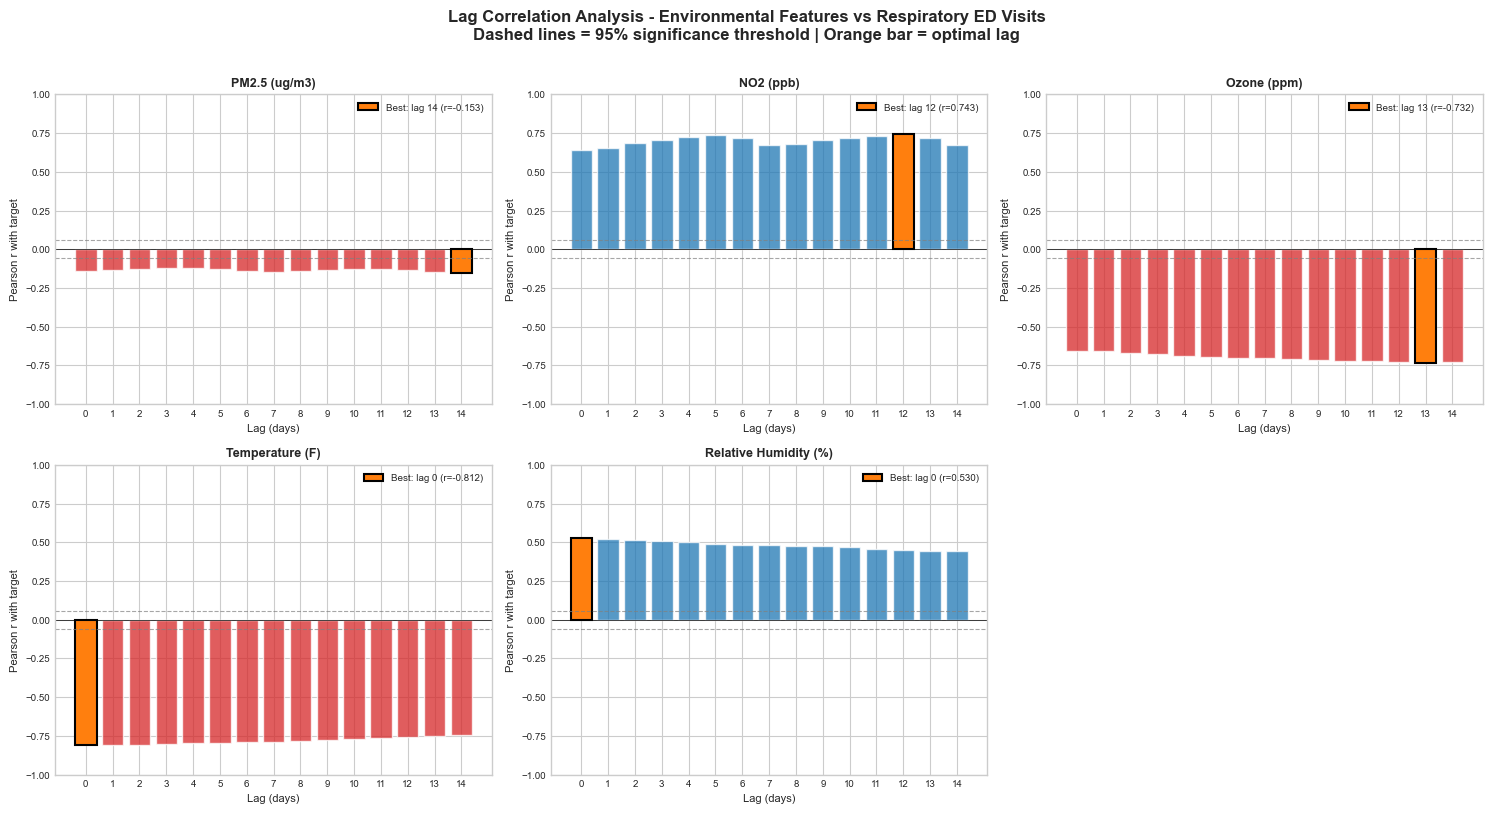

In [8]:
# Plot lag correlations for all features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    corrs  = lag_results[feat]['correlations']
    pvals  = lag_results[feat]['p_values']
    lags   = list(range(MAX_LAG + 1))
    colors = ['#d62728' if c < 0 else '#1f77b4' for c in corrs]

    bars = ax.bar(lags, corrs, color=colors, alpha=0.75, edgecolor='white')

    # Mark the optimal lag
    best = optimal_lags[feat]
    ax.bar(best, corrs[best], color='#ff7f0e', alpha=1.0, edgecolor='black', linewidth=1.5,
           label=f'Best: lag {best} (r={corrs[best]:.3f})')

    # Mark significance threshold (p < 0.05)
    sig_threshold = stats.pearsonr(
        np.random.randn(len(master) - MAX_LAG),
        np.random.randn(len(master) - MAX_LAG)
    )
    # Approximate 95% CI for zero correlation
    n_eff = len(master) - MAX_LAG
    sig_r = 1.96 / np.sqrt(n_eff)
    ax.axhline(sig_r,  color='gray', linewidth=0.8, linestyle='--', alpha=0.7)
    ax.axhline(-sig_r, color='gray', linewidth=0.8, linestyle='--', alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.5)

    ax.set_title(f'{LABELS[feat]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Lag (days)', fontsize=8)
    ax.set_ylabel('Pearson r with target', fontsize=8)
    ax.set_xticks(lags)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)
    ax.set_ylim(-1, 1)

axes[-1].set_visible(False)

fig.suptitle(
    'Lag Correlation Analysis - Environmental Features vs Respiratory ED Visits\n'
    'Dashed lines = 95% significance threshold | Orange bar = optimal lag',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('outputs/figures/eda_06_lag_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

---
## EDA 7 - Overlay: Respiratory vs Each Feature

Plot the target variable and each feature together using a dual y-axis. This lets us visually check whether the peaks and troughs in the features line up with respiratory illness patterns-whether they match immediately or with a noticeable lag.

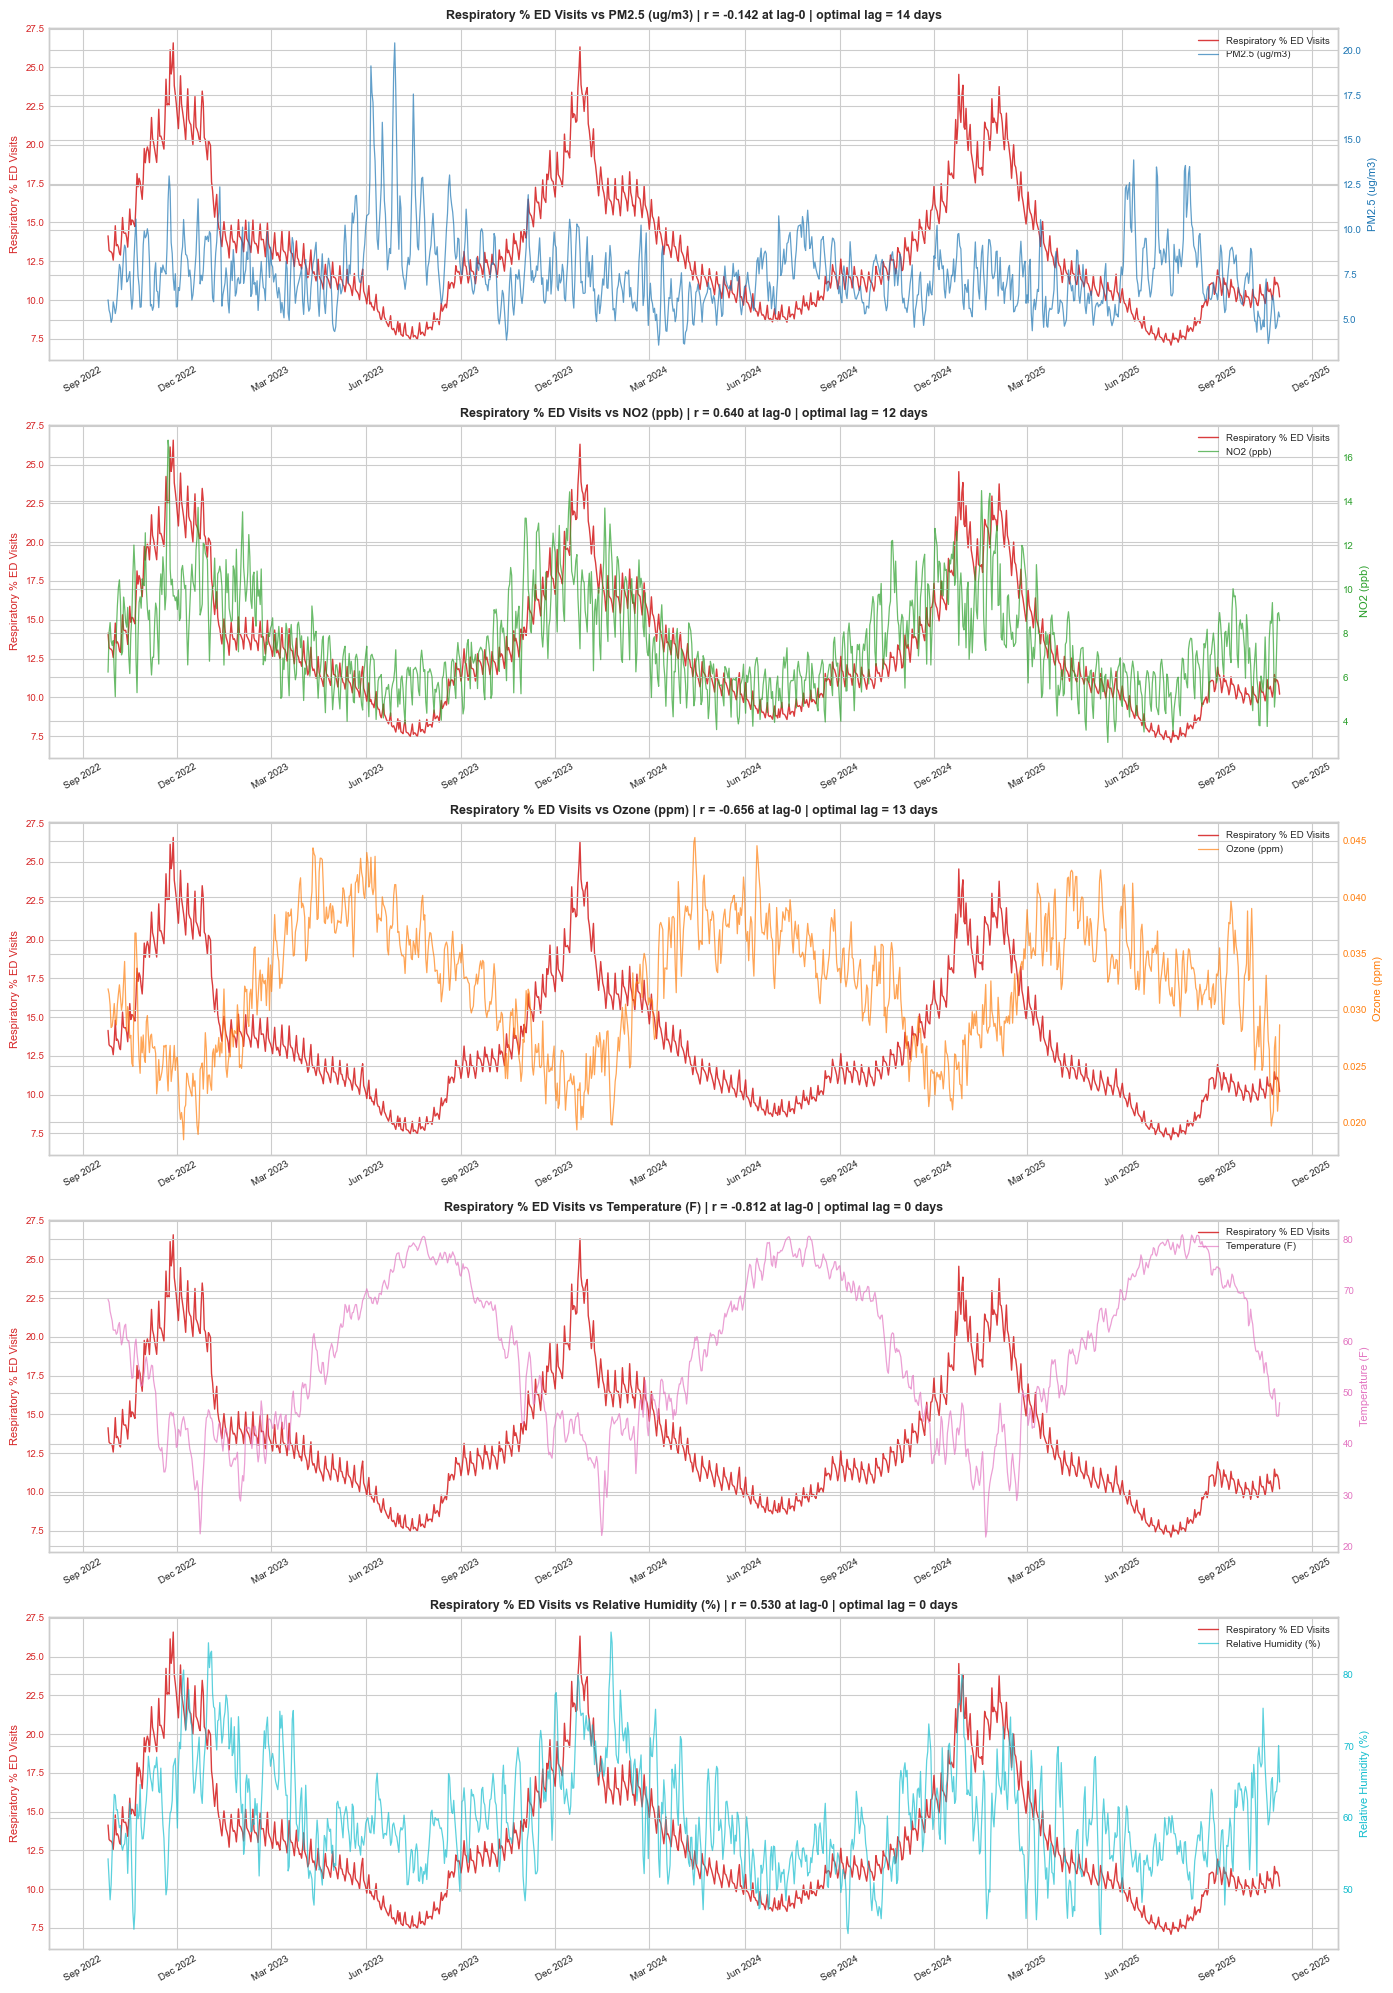

In [ ]:
fig, axes = plt.subplots(len(FEATURES), 1, figsize=(14, 4 * len(FEATURES)))

for ax, feat in zip(axes, FEATURES):
    ax2 = ax.twinx()

    l1, = ax.plot(master['date'], master[TARGET],
                  color=COLORS[TARGET], linewidth=1.0, alpha=0.9,
                  label=LABELS[TARGET])
    l2, = ax2.plot(master['date'], master[feat],
                   color=COLORS[feat], linewidth=0.9, alpha=0.7,
                   label=LABELS[feat])

    ax.set_ylabel(LABELS[TARGET], fontsize=8, color=COLORS[TARGET])
    ax2.set_ylabel(LABELS[feat], fontsize=8, color=COLORS[feat])
    ax.tick_params(axis='y', labelcolor=COLORS[TARGET], labelsize=7)
    ax2.tick_params(axis='y', labelcolor=COLORS[feat], labelsize=7)

    r = master[[TARGET, feat]].corr().iloc[0, 1]
    best_lag = optimal_lags[feat]
    ax.set_title(
        f'{LABELS[TARGET]} vs {LABELS[feat]} | '
        f'r = {r:.3f} at lag-0 | optimal lag = {best_lag} days',
        fontsize=9, fontweight='bold'
    )
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', labelsize=7, rotation=30)

    lines  = [l1, l2]
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper right', fontsize=7)

plt.tight_layout()
plt.savefig('outputs/figures/eda_07_overlay_respiratory_vs_features.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## EDA 8 — Rolling Correlation

The overall Pearson correlation assumes the relationship between a feature and the target is constant over the whole time period.
Rolling correlation, on the other hand, lets us see if that relationship stays consistent over time or varies by season or year.
For example, temperature might only correlate with respiratory visits in winter, while PM2.5 spikes from wildfires could affect visits at any time of year.

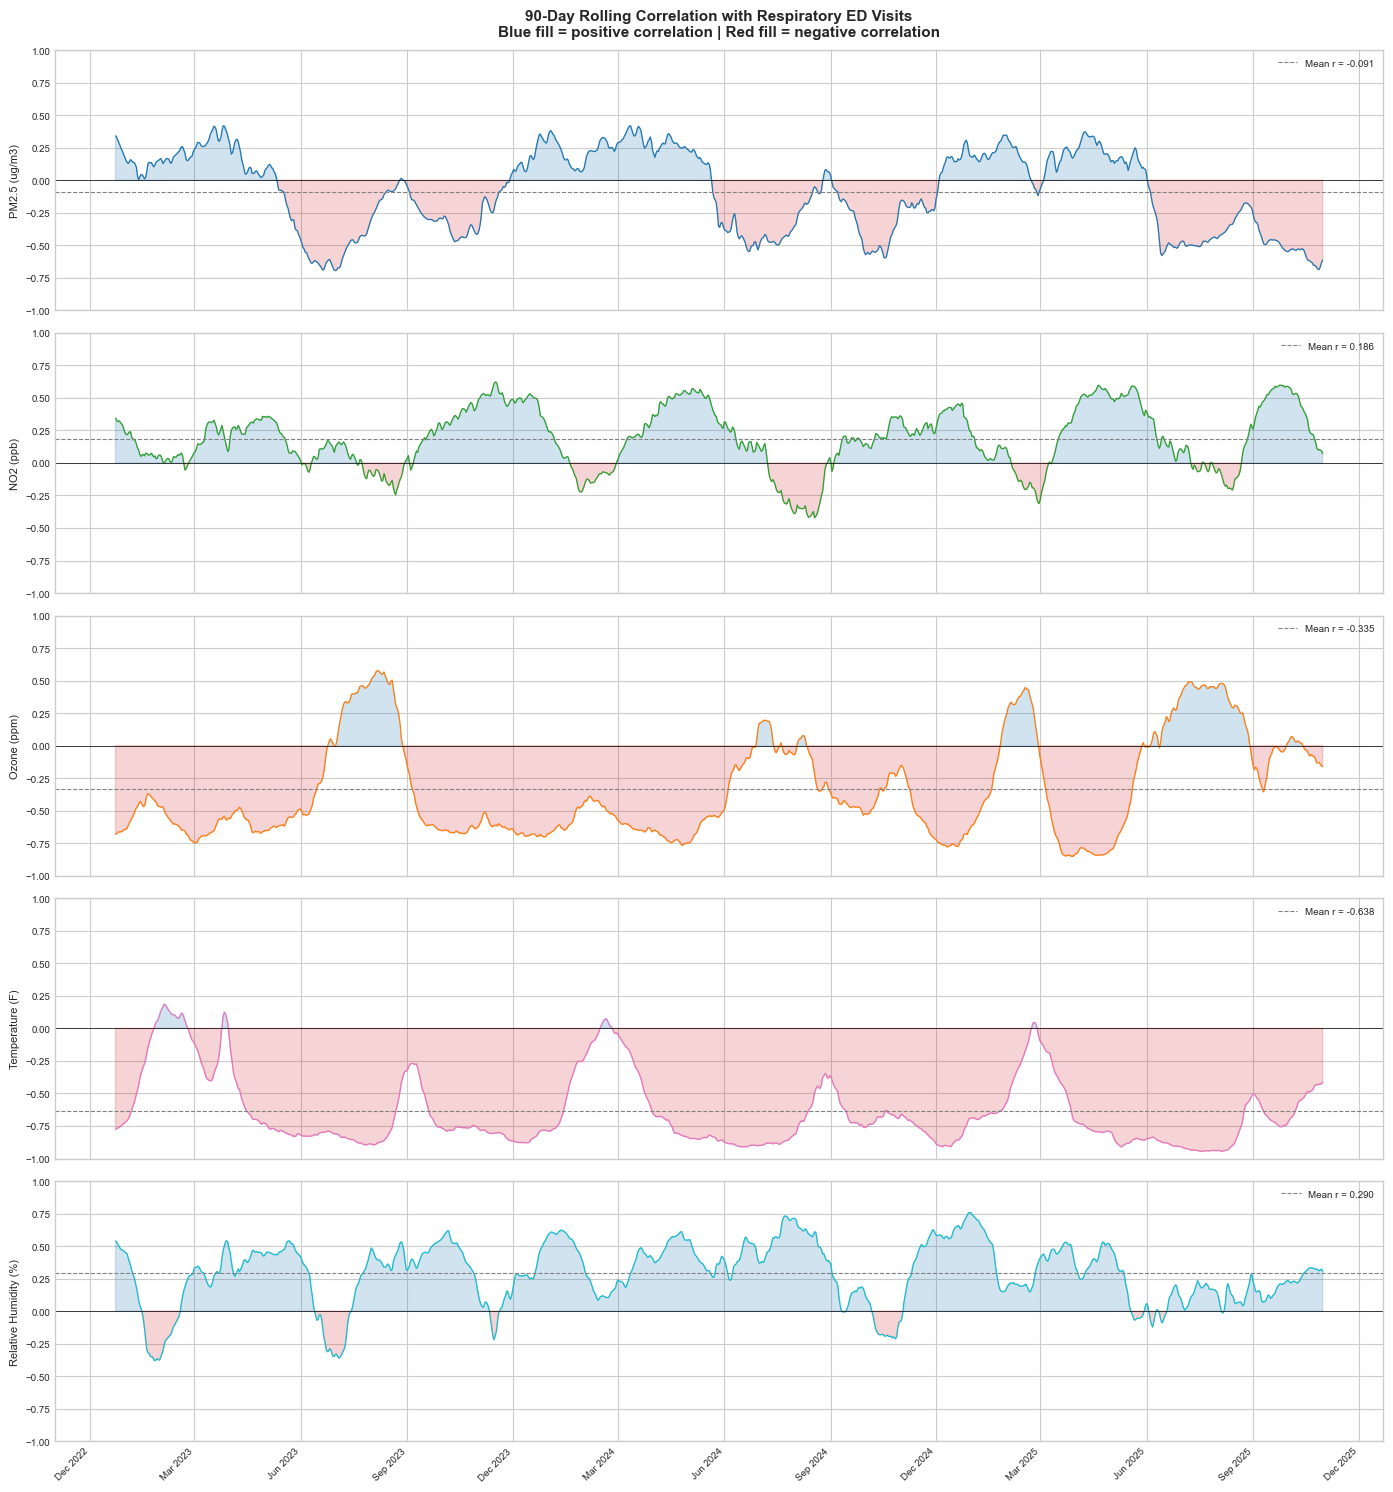

In [10]:
WINDOW = 90  # 90-day rolling window

fig, axes = plt.subplots(len(FEATURES), 1, figsize=(14, 3 * len(FEATURES)), sharex=True)

for ax, feat in zip(axes, FEATURES):
    rolling_r = master[TARGET].rolling(window=WINDOW).corr(master[feat])
    ax.plot(master['date'], rolling_r, color=COLORS[feat], linewidth=0.9)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.fill_between(master['date'], rolling_r, 0,
                    where=(rolling_r > 0), alpha=0.2, color='#1f77b4')
    ax.fill_between(master['date'], rolling_r, 0,
                    where=(rolling_r < 0), alpha=0.2, color='#d62728')
    mean_r = rolling_r.mean()
    ax.axhline(mean_r, color='gray', linewidth=0.8, linestyle='--',
               label=f'Mean r = {mean_r:.3f}')
    ax.set_ylabel(LABELS[feat], fontsize=8)
    ax.set_ylim(-1, 1)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7, loc='upper right')

axes[0].set_title(
    f'{WINDOW}-Day Rolling Correlation with Respiratory ED Visits\n'
    'Blue fill = positive correlation | Red fill = negative correlation',
    fontsize=11, fontweight='bold', pad=10
)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/figures/eda_08_rolling_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## EDA 9 - Day-of-Week Effect

The profiling phase identified a weekly oscillation in the respiratory data.
This cell quantifies it - confirming whether day of week should be a model feature.

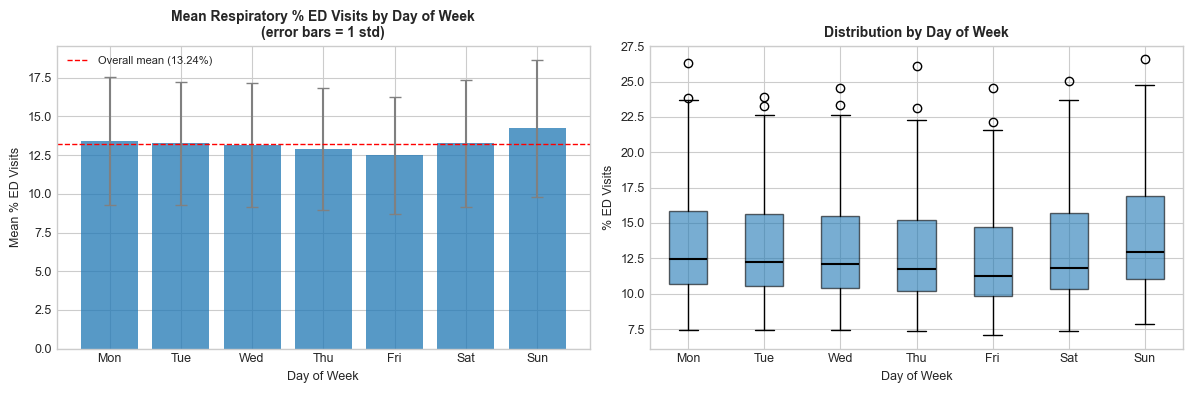

One-way ANOVA for day-of-week effect:
  F = 2.786 | p = 0.010778
  Result: Day-of-week effect is statistically significant.
  Decision: Add day_of_week as a feature in the model.


In [11]:
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_means  = master.groupby('dayofweek')[TARGET].mean()
dow_std    = master.groupby('dayofweek')[TARGET].std()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart - mean by day of week
axes[0].bar(dow_labels, dow_means.values, color='#1f77b4', alpha=0.75,
            yerr=dow_std.values, capsize=4, ecolor='gray')
axes[0].set_title('Mean Respiratory % ED Visits by Day of Week\n(error bars = 1 std)',
                  fontsize=10, fontweight='bold')
axes[0].set_ylabel('Mean % ED Visits', fontsize=9)
axes[0].set_xlabel('Day of Week', fontsize=9)
overall_mean = master[TARGET].mean()
axes[0].axhline(overall_mean, color='red', linewidth=1, linestyle='--',
                label=f'Overall mean ({overall_mean:.2f}%)')
axes[0].legend(fontsize=8)

# Box plot - distribution by day of week
dow_groups = [master[master['dayofweek'] == d][TARGET].values for d in range(7)]
bp = axes[1].boxplot(dow_groups, labels=dow_labels, patch_artist=True,
                     medianprops=dict(color='black', linewidth=1.5))
for patch in bp['boxes']:
    patch.set_facecolor('#1f77b4')
    patch.set_alpha(0.6)
axes[1].set_title('Distribution by Day of Week', fontsize=10, fontweight='bold')
axes[1].set_ylabel('% ED Visits', fontsize=9)
axes[1].set_xlabel('Day of Week', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/figures/eda_09_day_of_week_effect.png', dpi=150, bbox_inches='tight')
plt.show()

# ANOVA test: is the day-of-week effect statistically significant?
f_stat, p_anova = stats.f_oneway(*dow_groups)
print(f'One-way ANOVA for day-of-week effect:')
print(f'  F = {f_stat:.3f} | p = {p_anova:.6f}')
if p_anova < 0.05:
    print('  Result: Day-of-week effect is statistically significant.')
    print('  Decision: Add day_of_week as a feature in the model.')
else:
    print('  Result: Day-of-week effect is NOT statistically significant.')
    print('  Decision: Day-of-week feature may not be needed.')

---
## EDA Summary and Feature Engineering Decisions

In [12]:
print('EDA SUMMARY')

print('\n1. Correlations at lag-0:')
for feat in FEATURES:
    r = master[[TARGET, feat]].corr().iloc[0, 1]
    print(f'   {LABELS[feat]:<30}  r = {r:+.3f}')

print('\n2. Optimal lag per feature:')
for feat, lag in optimal_lags.items():
    best_r = lag_results[feat]['correlations'][lag]
    print(f'   {LABELS[feat]:<30}  lag = {lag} days | r = {best_r:+.3f}')

print('\n3. Feature engineering plan for modeling:')
print('   Based on lag analysis, the following features will be created:')
print()
print('   Feature                          Source column    Lag')
print('   ' + '-' * 55)
for feat in FEATURES:
    lag = optimal_lags[feat]
    if lag == 0:
        print(f'   {feat:<35} {feat:<15}  same day')
    else:
        print(f'   {feat}_lag{lag:<31} {feat:<15}  {lag} days prior')
print('   month                            date             seasonality')
print('   day_of_week                      date             weekly pattern')


EDA SUMMARY

1. Correlations at lag-0:
   PM2.5 (ug/m3)                   r = -0.142
   NO2 (ppb)                       r = +0.640
   Ozone (ppm)                     r = -0.656
   Temperature (F)                 r = -0.812
   Relative Humidity (%)           r = +0.530

2. Optimal lag per feature:
   PM2.5 (ug/m3)                   lag = 14 days | r = -0.153
   NO2 (ppb)                       lag = 12 days | r = +0.743
   Ozone (ppm)                     lag = 13 days | r = -0.732
   Temperature (F)                 lag = 0 days | r = -0.812
   Relative Humidity (%)           lag = 0 days | r = +0.530

3. Feature engineering plan for modeling:
   Based on lag analysis, the following features will be created:

   Feature                          Source column    Lag
   -------------------------------------------------------
   pm25_lag14                              pm25             14 days prior
   no2_lag12                              no2              12 days prior
   ozone_lag13       

---
## Feature Engineering

Based on EDA findings, create the final feature set for modeling.
Save the enriched dataset to `data/processed/features_daily.csv`.

In [13]:
features_df = master[['date', TARGET] + FEATURES].copy()

# Add lagged features based on optimal lag analysis
for feat in FEATURES:
    lag = optimal_lags[feat]
    if lag > 0:
        features_df[f'{feat}_lag{lag}'] = features_df[feat].shift(lag)

# Add temporal features
features_df['month']       = features_df['date'].dt.month
features_df['day_of_week'] = features_df['date'].dt.dayofweek
features_df['is_weekend']  = (features_df['day_of_week'] >= 5).astype(int)
features_df['season_num']  = features_df['month'].map({
    12: 0, 1: 0, 2: 0,   # Winter = 0
    3: 1,  4: 1, 5: 1,   # Spring = 1
    6: 2,  7: 2, 8: 2,   # Summer = 2
    9: 3,  10: 3, 11: 3  # Fall   = 3
})

# Drop rows with NaN from lagging (first N rows)
max_lag = max(optimal_lags.values()) if any(v > 0 for v in optimal_lags.values()) else 0
features_df = features_df.dropna().reset_index(drop=True)

print(f'Features dataset shape: {features_df.shape}')
print(f'Date range: {features_df["date"].min().date()} to {features_df["date"].max().date()}')
print(f'Rows dropped due to lag NaN: {len(master) - len(features_df)}')
print(f'\nColumns in features dataset:')
for col in features_df.columns:
    print(f'  {col}')

features_df.to_csv('data/processed/features_daily.csv', index=False)
size_kb = os.path.getsize('data/processed/features_daily.csv') / 1024
print(f'\nSaved: data/processed/features_daily.csv  ({size_kb:.1f} KB)')

Features dataset shape: (1119, 14)
Date range: 2022-10-09 to 2025-10-31
Rows dropped due to lag NaN: 14

Columns in features dataset:
  date
  pct_respiratory
  pm25
  no2
  ozone
  temperature
  humidity
  pm25_lag14
  no2_lag12
  ozone_lag13
  month
  day_of_week
  is_weekend
  season_num

Saved: data/processed/features_daily.csv  (187.2 KB)
